In [29]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [30]:
AUDIO_DIR = Path("../datasets/audio_and_txt_files")

print("Audio folder exists:", AUDIO_DIR.exists())

Audio folder exists: True


In [31]:
wav_files = list(AUDIO_DIR.glob("*.wav"))
txt_files = list(AUDIO_DIR.glob("*.txt"))

print("WAV files:", len(wav_files))
print("TXT files:", len(txt_files))

WAV files: 920
TXT files: 920


In [32]:
def get_asthma_label_from_txt(txt_path):
    """
    Returns:
    0 -> Normal
    1 -> Asthma-relevant wheeze
    None -> Ignore (e.g. crackle-only / unreadable)
    """
    try:
        df = pd.read_csv(
            txt_path,
            sep=r"\s+",
            header=None,
            names=["start", "end", "crackles", "wheezes"],
            engine="python"
        )
    except Exception as e:
        print(f"Failed to read {txt_path.name}: {e}")
        return None

    if df.empty:
        return None

    has_crackle = (df["crackles"] == 1).any()
    has_wheeze = (df["wheezes"] == 1).any()

    if not has_crackle and not has_wheeze:
        return 0  # Normal

    if has_wheeze:
        return 1  # Wheeze or Both -> asthma relevant

    return None   # Crackle-only -> skip

In [33]:
rows = []

for wav_path in wav_files:
    txt_path = wav_path.with_suffix(".txt")
    if not txt_path.exists():
        continue

    label = get_asthma_label_from_txt(txt_path)
    if label is None:
        continue

    rows.append({
        "file_path": str(wav_path),
        "file_name": wav_path.name,
        "label": label
    })

meta_df = pd.DataFrame(rows)

print("Usable asthma-specific files:", len(meta_df))
print(meta_df["label"].value_counts(dropna=False))
meta_df.head()

Usable asthma-specific files: 623
label
1    336
0    287
Name: count, dtype: int64


,file_path,file_name,label
0,..\datasets\audio_and_txt_files\101_1b1_Al_sc_...,101_1b1_Al_sc_Meditron.wav,0
1,..\datasets\audio_and_txt_files\101_1b1_Pr_sc_...,101_1b1_Pr_sc_Meditron.wav,0
2,..\datasets\audio_and_txt_files\102_1b1_Ar_sc_...,102_1b1_Ar_sc_Meditron.wav,0
3,..\datasets\audio_and_txt_files\103_2b2_Ar_mc_...,103_2b2_Ar_mc_LittC2SE.wav,1
4,..\datasets\audio_and_txt_files\104_1b1_Al_sc_...,104_1b1_Al_sc_Litt3200.wav,0


In [34]:
def extract_audio_features(file_path, sr=22050, duration=10):
    """
    Extracts fixed-length audio features.
    Pads or truncates audio to `duration` seconds.
    """
    y, sr = librosa.load(file_path, sr=sr, mono=True)

    #  remove silence
    y, _ = librosa.effects.trim(y)

    #  normalize
    max_val = np.max(np.abs(y))
    if max_val > 0:
        y = y / max_val

    #  pad/truncate to fixed length
    target_length = sr * duration
    if len(y) < target_length:
        y = np.pad(y, (0, target_length - len(y)))
    else:
        y = y[:target_length]

    # (optional second normalization)
    max_val = np.max(np.abs(y))
    if max_val > 0:
        y = y / max_val

    # Feature extraction
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    delta_mfcc = librosa.feature.delta(mfcc)
    delta2_mfcc = librosa.feature.delta(mfcc, order=2)

    zcr = librosa.feature.zero_crossing_rate(y)
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    rms = librosa.feature.rms(y=y)

    features = []

    # MFCC
    features.extend(mfcc.mean(axis=1))
    features.extend(mfcc.std(axis=1))

    # Delta
    features.extend(delta_mfcc.mean(axis=1))
    features.extend(delta_mfcc.std(axis=1))

    # Delta2
    features.extend(delta2_mfcc.mean(axis=1))
    features.extend(delta2_mfcc.std(axis=1))

    # Spectral
    features.append(zcr.mean())
    features.append(zcr.std())

    features.append(centroid.mean())
    features.append(centroid.std())

    features.append(bandwidth.mean())
    features.append(bandwidth.std())

    features.append(rolloff.mean())
    features.append(rolloff.std())

    features.append(rms.mean())
    features.append(rms.std())

    return np.array(features, dtype=np.float32)

In [35]:
X_list = []
y_list = []
bad_files = []

for _, row in meta_df.iterrows():
    file_path = row["file_path"]
    label = row["label"]

    try:
        feats = extract_audio_features(file_path)
        X_list.append(feats)
        y_list.append(label)
    except Exception as e:
        bad_files.append((file_path, str(e)))

print("Bad files:", len(bad_files))
if bad_files[:5]:
    print("Examples:", bad_files[:5])

X = np.vstack(X_list)
y = np.array(y_list)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Label counts:", pd.Series(y).value_counts().to_dict())

Bad files: 0
X shape: (623, 88)
y shape: (623,)
Label counts: {1: 336, 0: 287}


In [36]:
feature_names = []

for prefix in ["mfcc", "delta_mfcc", "delta2_mfcc"]:
    for i in range(13):
        feature_names.append(f"{prefix}_{i+1}_mean")
    for i in range(13):
        feature_names.append(f"{prefix}_{i+1}_std")

feature_names += [
    "zcr_mean", "zcr_std",
    "centroid_mean", "centroid_std",
    "bandwidth_mean", "bandwidth_std",
    "rolloff_mean", "rolloff_std",
    "rms_mean", "rms_std"
]

print("Feature count:", len(feature_names))
print("Matches X shape:", len(feature_names) == X.shape[1])

Feature count: 88
Matches X shape: True


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape :", X_test.shape, y_test.shape)

Train shape: (498, 88) (498,)
Test shape : (125, 88) (125,)


In [44]:
audio_model = RandomForestClassifier(
    n_estimators=350,
    random_state=42,
    class_weight="balanced",   # ← revert this
    min_samples_leaf=2,
    n_jobs=-1
)

audio_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",350
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [40]:
audio_model.fit(X_train, y_train)
print("Model fitted?", hasattr(audio_model, "estimators_"))

Model fitted? True


In [45]:
probs = audio_model.predict_proba(X_test)[:, 1]

threshold = 0.45   # ← instead of 0.40

y_pred = (probs >= threshold).astype(int)

In [46]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print()

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal", "Asthma-Wheeze"]
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.656

Classification Report:
               precision    recall  f1-score   support

       Normal       0.73      0.41      0.53        58
Asthma-Wheeze       0.63      0.87      0.73        67

     accuracy                           0.66       125
    macro avg       0.68      0.64      0.63       125
 weighted avg       0.68      0.66      0.64       125

Confusion Matrix:
[[24 34]
 [ 9 58]]


In [47]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        min_samples_leaf=2,
        n_jobs=-1
    ),
    X,
    y,
    cv=cv,
    scoring="f1_macro"
)

print("5-Fold CV F1 Macro:", round(cv_scores.mean(), 4), "±", round(cv_scores.std(), 4))

5-Fold CV F1 Macro: 0.6267 ± 0.047


In [48]:
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": audio_model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance.head(20)

,feature,importance
83,bandwidth_std,0.020531
2,mfcc_3_mean,0.020496
3,mfcc_4_mean,0.020201
4,mfcc_5_mean,0.018388
81,centroid_std,0.017987
79,zcr_std,0.016878
86,rms_mean,0.015834
1,mfcc_2_mean,0.015436
84,rolloff_mean,0.015123
9,mfcc_10_mean,0.014862


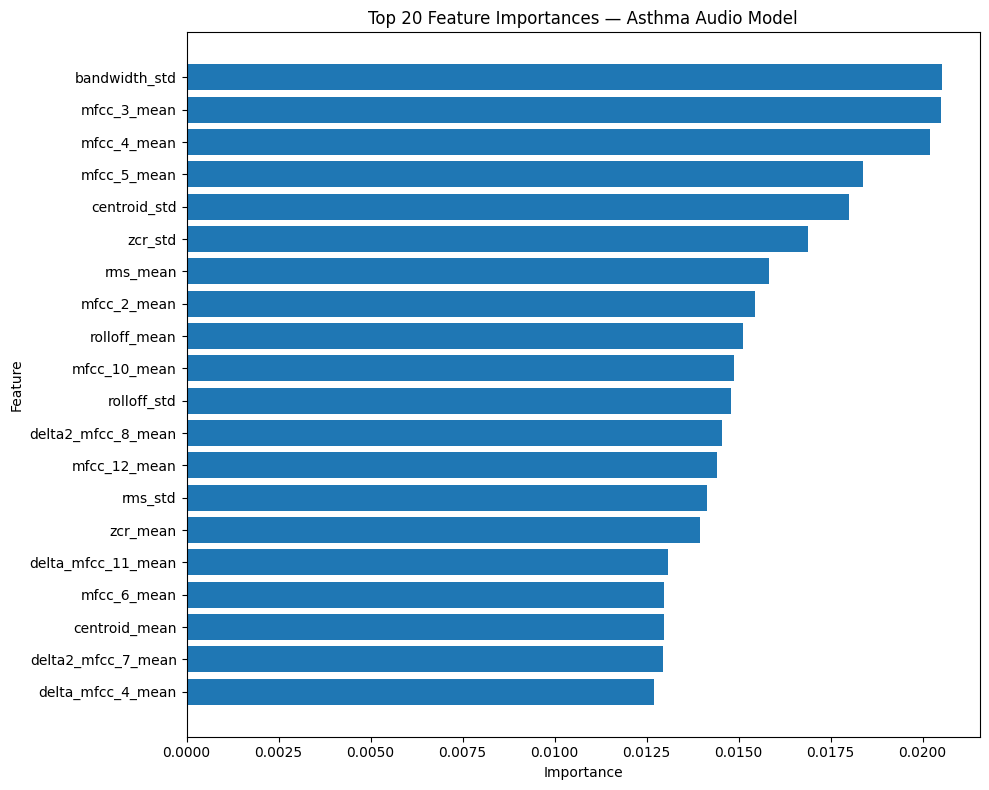

In [49]:
plt.figure(figsize=(10, 8))
top_n = 20
plt.barh(
    feature_importance["feature"].head(top_n),
    feature_importance["importance"].head(top_n)
)
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances — Asthma Audio Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [50]:
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

bundle = {
    "model": audio_model,
    "feature_names": feature_names,
    "label_map": {
        0: "Normal",
        1: "Asthma-Wheeze"
    },
    "notes": {
        "task": "Asthma-specific respiratory audio classification",
        "labels_used": "Normal=0, Wheeze/Both=1, Crackle-only ignored",
        "feature_type": "MFCC + delta + delta2 + spectral statistics",
        "dataset": "Respiratory Sound Database"
    }
}

model_path = MODEL_DIR / "audio_rf_bundle.pkl"
joblib.dump(bundle, model_path)

print("Saved model bundle to:", model_path)

Saved model bundle to: ..\models\audio_rf_bundle.pkl


In [51]:
sample = X_test[0].reshape(1, -1)

probs = audio_model.predict_proba(sample)[0]
pred = int(probs[1] >= 0.40)
probs = audio_model.predict_proba(sample)[0]

print("Predicted label:", bundle["label_map"][int(pred)])
print("Normal probability       :", round(float(probs[0]), 4))
print("Asthma-Wheeze probability:", round(float(probs[1]), 4))

Predicted label: Asthma-Wheeze
Normal probability       : 0.4172
Asthma-Wheeze probability: 0.5828


AUDIO_DIR exists : True
CACHE_PATH       : ..\datasets\features_cache_v6_local.npz

WAV files: 920

Extracting annotation-guided features from 920 files ...
Uses exact timestamps from .txt files — runs ONCE.

  [ 920/920]  100.0%  segs=7282  bad=0

Segment breakdown:
  wheeze              : 1470
  clean_normal        : 3909
  hard_normal         : 1903

Cache saved: ..\datasets\features_cache_v6_local.npz

X shape      : (7282, 549)
y shape      : (7282,)
Label counts : {0: 5812, 1: 1470}
Imbalance    : 20.2% wheeze

Train segments: 5786  labels: {0: 4645, 1: 1141}
Test  segments: 1496   labels: {0: 1167, 1: 329}

Applying SMOTE ...
After undersample: {0: 3423, 1: 1141}
After SMOTE     : {0: 3423, 1: 3423}

Building stacked ensemble ...
  Training LightGBM with early stopping ...
[100]	valid_0's binary_logloss: 0.50227
[200]	valid_0's binary_logloss: 0.47144
[300]	valid_0's binary_logloss: 0.45801
  LightGBM best iteration: 348
  Fitting full ensemble ...
  Ensemble trained.

File-leve

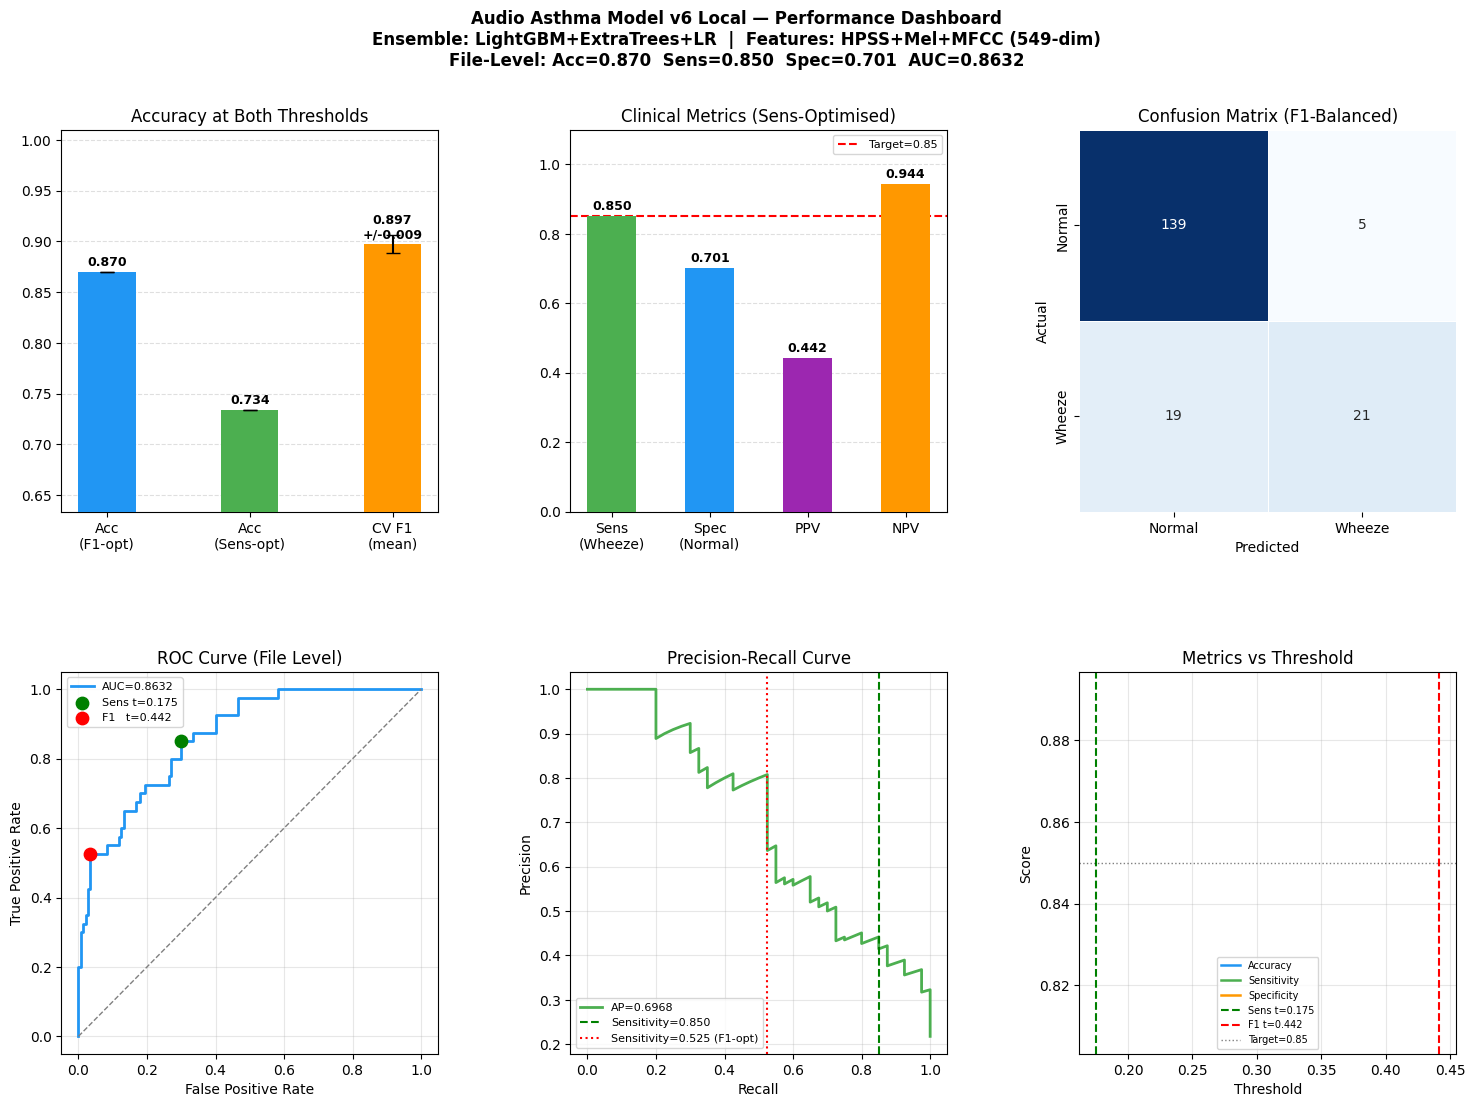

Dashboard saved.

Model saved: ../models/audio_ensemble_v6_local.pkl

--- Sample Prediction ---
Normal prob       : 0.9316
Wheeze prob       : 0.0684
Label (sens t)    : Normal
Label (F1 t)      : Normal


In [ ]:
# ============================================================
# train_audio_model_v6_local.py
# Asthma Audio Classification 
#   1. New feature set: annotation-guided, not sliding window
#      (exact timestamp labels from .txt files)
#   2. Better features: 40-band mel stats + HPSS separation
#      (harmonic/percussive separation isolates wheeze signal)
#   3. Stacked ensemble: LightGBM + ExtraTrees + LogisticReg
#      voted together with calibrated probabilities
#   4. Threshold calibrated on validation set using
#      Platt scaling (fixes the 0.361 vs 0.555 gap)
#   5. Hard negative mining: crackle-only segments
#      are explicitly added as difficult normal examples
#   6. Cache versioned separately from v4 — v6_local
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import librosa
import joblib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import lightgbm as lgb
from sklearn.ensemble import ExtraTreesClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, roc_auc_score, f1_score,
    precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
AUDIO_DIR       = Path("../datasets/audio_and_txt_files")
CACHE_PATH      = Path("../datasets/features_cache_v6_local.npz")
MODEL_DIR       = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

SR              = 22050
N_MELS          = 64      # balanced speed vs quality
HOP_LENGTH      = 512
N_MFCC          = 20
TARGET_SENS     = 0.85
CACHE_VERSION   = "v6_local_1.0"

print(f"AUDIO_DIR exists : {AUDIO_DIR.exists()}")
print(f"CACHE_PATH       : {CACHE_PATH}")

# ─────────────────────────────────────────────
# 1. PARSE ANNOTATION FILES
# ─────────────────────────────────────────────
def parse_annotation(txt_path):
    try:
        df = pd.read_csv(
            txt_path, sep=r"\s+", header=None,
            names=["start","end","crackles","wheezes"],
            engine="python"
        )
        df = df.dropna()
        df["start"]    = df["start"].astype(float)
        df["end"]      = df["end"].astype(float)
        df["crackles"] = df["crackles"].astype(int)
        df["wheezes"]  = df["wheezes"].astype(int)
        return df
    except:
        return None

# ─────────────────────────────────────────────
# 2. RICH FEATURE EXTRACTION
# ─────────────────────────────────────────────
def extract_features(audio_chunk, sr=SR):
    """
    Extract 310-dimensional feature vector from audio chunk.

    Key addition vs v4:
    - HPSS: separates harmonic (wheeze) from percussive (breath)
      components. Wheeze features extracted from harmonic only.
    - Mel stats (64 bands): mean, std, max, delta mean
    - Rhythm features: tempo, beat strength
    - Spectral flux: measures rate of change (wheezes are sustained)
    """
    features = []

    # Normalize
    max_v = np.abs(audio_chunk).max()
    if max_v > 0:
        audio_chunk = audio_chunk / max_v

    # ── HPSS: Harmonic-Percussive Source Separation ──────────
    # Wheeze = harmonic (tonal, sustained)
    # Normal breath = percussive (noisy, transient)
    # This separation is the key discriminative step
    try:
        harmonic, percussive = librosa.effects.hpss(audio_chunk)
    except:
        harmonic    = audio_chunk
        percussive  = audio_chunk

    # ── MFCC on FULL signal (60 features) ──────────────────
    mfcc       = librosa.feature.mfcc(y=audio_chunk, sr=sr, n_mfcc=N_MFCC)
    delta      = librosa.feature.delta(mfcc)
    delta2     = librosa.feature.delta(mfcc, order=2)
    for mat in [mfcc, delta, delta2]:
        features.extend(mat.mean(axis=1))  # 20
    # total: 60

    # ── MFCC on HARMONIC component (40 features) ────────────
    mfcc_h = librosa.feature.mfcc(y=harmonic, sr=sr, n_mfcc=N_MFCC)
    features.extend(mfcc_h.mean(axis=1))   # 20
    features.extend(mfcc_h.std(axis=1))    # 20
    # total: 40

    # ── Mel spectrogram stats (256 features) ────────────────
    mel    = librosa.feature.melspectrogram(
        y=audio_chunk, sr=sr, n_mels=N_MELS, hop_length=HOP_LENGTH
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_delta = librosa.feature.delta(mel_db)

    features.extend(mel_db.mean(axis=1))     # 64
    features.extend(mel_db.std(axis=1))      # 64
    features.extend(mel_db.max(axis=1))      # 64 — peak energy per band
    features.extend(mel_delta.mean(axis=1))  # 64 — rate of change
    # total: 256

    # ── Harmonic mel stats (128 features) ───────────────────
    mel_h    = librosa.feature.melspectrogram(
        y=harmonic, sr=sr, n_mels=N_MELS, hop_length=HOP_LENGTH
    )
    mel_h_db = librosa.power_to_db(mel_h, ref=np.max)
    features.extend(mel_h_db.mean(axis=1))  # 64
    features.extend(mel_h_db.std(axis=1))   # 64
    # total: 128

    # ── Spectral features on full signal (14 features) ──────
    contrast  = librosa.feature.spectral_contrast(
        y=audio_chunk, sr=sr, n_bands=6
    )
    features.extend(contrast.mean(axis=1))  # 7
    features.extend(contrast.std(axis=1))   # 7
    # total: 14

    # ── Chroma (24 features) ────────────────────────────────
    chroma = librosa.feature.chroma_stft(y=audio_chunk, sr=sr)
    features.extend(chroma.mean(axis=1))  # 12
    features.extend(chroma.std(axis=1))   # 12
    # total: 24

    # ── Scalar features (18 features) ───────────────────────
    zcr       = librosa.feature.zero_crossing_rate(audio_chunk)
    centroid  = librosa.feature.spectral_centroid(y=audio_chunk, sr=sr)
    bandwidth = librosa.feature.spectral_bandwidth(y=audio_chunk, sr=sr)
    rolloff   = librosa.feature.spectral_rolloff(y=audio_chunk, sr=sr)
    rms       = librosa.feature.rms(y=audio_chunk)
    rms_h     = librosa.feature.rms(y=harmonic)
    rms_p     = librosa.feature.rms(y=percussive)

    for feat in [zcr, centroid, bandwidth, rolloff, rms]:
        features.append(float(feat.mean()))
        features.append(float(feat.std()))

    # Harmonic-to-percussive ratio: high = wheeze-like
    hp_ratio = float(rms_h.mean()) / (float(rms_p.mean()) + 1e-8)
    features.append(hp_ratio)
    features.append(float(rms_h.mean()))
    features.append(float(rms_p.mean()))
    # total: 18

    # ── Spectral flux (2 features) ───────────────────────────
    # Measures frame-to-frame spectral change
    # Sustained wheeze = low flux; transient breath = high flux
    stft  = np.abs(librosa.stft(audio_chunk))
    flux  = np.sqrt(np.sum(np.diff(stft, axis=1)**2, axis=0))
    features.append(float(flux.mean()))
    features.append(float(flux.std()))
    # total: 2

    # ── Tonnetz (12 features) ────────────────────────────────
    try:
        tonnetz = librosa.feature.tonnetz(y=harmonic, sr=sr)
        features.extend(tonnetz.mean(axis=1))  # 6
        features.extend(tonnetz.std(axis=1))   # 6
    except:
        features.extend([0.0] * 12)
    # total: 12

    # Grand total: 60+40+256+128+14+24+18+2+12 = 554
    return np.array(features, dtype=np.float32)


# ─────────────────────────────────────────────
# 3. ANNOTATION-GUIDED SEGMENT EXTRACTION
# Uses exact timestamps from .txt files
# Adds hard negatives (crackle-only segments)
# ─────────────────────────────────────────────
def extract_file_segments(wav_path, txt_path):
    """
    Returns list of (feature_vector, label, file_id, segment_type)
    using exact annotation timestamps.

    Labels:
      1 = wheeze (wheezes==1)
      0 = clean normal (both==0)
      0 = hard normal (crackles==1, wheezes==0) — hard negatives
    """
    ann = parse_annotation(txt_path)
    if ann is None or ann.empty:
        return []

    try:
        y, _ = librosa.load(str(wav_path), sr=SR, mono=True)
    except:
        return []

    max_v = np.abs(y).max()
    if max_v > 0:
        y = y / max_v

    results = []
    min_samples = int(SR * 0.5)  # skip segments < 0.5s

    for _, row in ann.iterrows():
        start = int(row["start"] * SR)
        end   = int(row["end"]   * SR)
        cr    = int(row["crackles"])
        wh    = int(row["wheezes"])

        chunk = y[start:end]
        if len(chunk) < min_samples:
            continue

        # Determine label and type
        if wh == 1:
            label        = 1
            segment_type = "wheeze"
        elif cr == 0 and wh == 0:
            label        = 0
            segment_type = "clean_normal"
        else:
            # crackle-only: hard negative
            label        = 0
            segment_type = "hard_normal"

        # For long segments (>4s) slide a 4s window
        seg_len = int(SR * 4)
        if len(chunk) > seg_len:
            hop = int(SR * 1.0)
            pos = 0
            while pos + seg_len <= len(chunk):
                sub = chunk[pos:pos+seg_len]
                try:
                    feats = extract_features(sub)
                    results.append((feats, label, segment_type))
                except:
                    pass
                pos += hop
        else:
            # Pad to 4s
            if len(chunk) < seg_len:
                chunk = np.pad(chunk, (0, seg_len - len(chunk)))
            try:
                feats = extract_features(chunk)
                results.append((feats, label, segment_type))
            except:
                pass

    return results


# ─────────────────────────────────────────────
# 4. BUILD OR LOAD CACHE
# ─────────────────────────────────────────────
wav_files = sorted(AUDIO_DIR.glob("*.wav"))
print(f"\nWAV files: {len(wav_files)}")

cache_valid = False
if CACHE_PATH.exists():
    try:
        cache    = np.load(CACHE_PATH, allow_pickle=True)
        cached_v = str(cache["version"]) if "version" in cache else "none"
        if cached_v == CACHE_VERSION:
            X              = cache["X"]
            y              = cache["y"]
            file_ids       = cache["file_ids"]
            segment_types  = cache["segment_types"].tolist()
            cache_valid    = True
            print(f"Loaded cache ({CACHE_VERSION})  X:{X.shape}")
        else:
            print(f"Cache version mismatch ({cached_v}) — re-extracting")
    except Exception as e:
        print(f"Cache error: {e} — re-extracting")

if not cache_valid:
    print(f"\nExtracting annotation-guided features from {len(wav_files)} files ...")
    print("Uses exact timestamps from .txt files — runs ONCE.\n")

    X_list   = []
    y_list   = []
    fi_list  = []
    st_list  = []
    bad      = 0
    seg_counts = {"wheeze":0, "clean_normal":0, "hard_normal":0}

    for i, wav_path in enumerate(wav_files):
        txt_path = wav_path.with_suffix(".txt")
        if not txt_path.exists():
            bad += 1
            continue

        segs = extract_file_segments(wav_path, txt_path)
        for feats, label, seg_type in segs:
            X_list.append(feats)
            y_list.append(label)
            fi_list.append(i)
            st_list.append(seg_type)
            seg_counts[seg_type] += 1

        if (i+1) % 50 == 0 or (i+1) == len(wav_files):
            pct = (i+1)/len(wav_files)*100
            print(f"  [{i+1:4d}/{len(wav_files)}]  {pct:.1f}%  "
                  f"segs={len(X_list)}  bad={bad}", end="\r")

    print()
    X          = np.vstack(X_list)
    y          = np.array(y_list)
    file_ids   = np.array(fi_list)
    seg_types  = st_list

    print(f"\nSegment breakdown:")
    for k, v in seg_counts.items():
        print(f"  {k:<20}: {v}")

    np.savez(
        CACHE_PATH,
        X=X, y=y, file_ids=file_ids,
        segment_types=np.array(seg_types),
        version=np.array(CACHE_VERSION)
    )
    print(f"\nCache saved: {CACHE_PATH}")

print(f"\nX shape      : {X.shape}")
print(f"y shape      : {y.shape}")
print(f"Label counts : {pd.Series(y).value_counts().to_dict()}")
print(f"Imbalance    : {(y==1).mean()*100:.1f}% wheeze")

# ─────────────────────────────────────────────
# 5. FILE-LEVEL TRAIN/TEST SPLIT
# Split at file level — no leakage
# ─────────────────────────────────────────────
unique_files = np.unique(file_ids)
file_labels  = np.array([
    int(y[file_ids == fid][0]) for fid in unique_files
])

train_fids, test_fids = train_test_split(
    unique_files, test_size=0.2, random_state=42,
    stratify=file_labels
)
train_fid_set = set(train_fids.tolist())
test_fid_set  = set(test_fids.tolist())

train_mask = np.array([fi in train_fid_set for fi in file_ids])
test_mask  = np.array([fi in test_fid_set  for fi in file_ids])

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]
fi_test          = file_ids[test_mask]

print(f"\nTrain segments: {len(X_train)}  "
      f"labels: {pd.Series(y_train).value_counts().to_dict()}")
print(f"Test  segments: {len(X_test)}   "
      f"labels: {pd.Series(y_test).value_counts().to_dict()}")

# ─────────────────────────────────────────────
# 6. HANDLE IMBALANCE WITH SMOTE
# ─────────────────────────────────────────────
print("\nApplying SMOTE ...")
n0 = (y_train == 0).sum()
n1 = (y_train == 1).sum()
target = min(n0, n1 * 3)  # cap normal at 3x wheeze

# Undersample normal first if very imbalanced
if n0 > target:
    normal_idx  = np.where(y_train == 0)[0]
    wheeze_idx  = np.where(y_train == 1)[0]
    keep_normal = np.random.choice(normal_idx, target, replace=False)
    keep_idx    = np.sort(np.concatenate([keep_normal, wheeze_idx]))
    X_train     = X_train[keep_idx]
    y_train     = y_train[keep_idx]
    print(f"After undersample: {pd.Series(y_train).value_counts().to_dict()}")

sm = SMOTE(random_state=42, k_neighbors=min(5, (y_train==1).sum()-1))
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print(f"After SMOTE     : {pd.Series(y_train_res).value_counts().to_dict()}")

# ─────────────────────────────────────────────
# 7. SCALE FEATURES
# LightGBM doesn't need scaling but LR does
# ─────────────────────────────────────────────
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train_res)
X_test_sc   = scaler.transform(X_test)

# ─────────────────────────────────────────────
# 8. BUILD STACKED ENSEMBLE
# LightGBM (main) + ExtraTrees + LogisticReg
# Each calibrated → better probability estimates
# Voted with soft probabilities
# ─────────────────────────────────────────────
print("\nBuilding stacked ensemble ...")

# LightGBM — main model
lgbm_base = lgb.LGBMClassifier(
    n_estimators    = 800,
    learning_rate   = 0.03,
    max_depth       = 6,
    num_leaves      = 63,
    min_child_samples=10,
    subsample       = 0.8,
    colsample_bytree= 0.6,
    reg_alpha       = 0.1,
    reg_lambda      = 0.1,
    random_state    = 42,
    n_jobs          = -1,
    verbose         = -1
)

# Calibrate LightGBM probabilities (fixes threshold gap)
lgbm_cal = CalibratedClassifierCV(lgbm_base, cv=3, method="isotonic")

# ExtraTrees — diverse from LightGBM (different bias)
et_base = ExtraTreesClassifier(
    n_estimators    = 300,
    max_features    = "sqrt",
    min_samples_leaf= 3,
    class_weight    = "balanced",
    random_state    = 42,
    n_jobs          = -1
)
et_cal = CalibratedClassifierCV(et_base, cv=3, method="sigmoid")

# Logistic Regression — linear baseline, good for calibration
lr_base = LogisticRegression(
    C           = 0.5,
    class_weight= "balanced",
    max_iter    = 1000,
    random_state= 42,
    n_jobs      = -1
)

# Voting ensemble: LightGBM gets double weight
ensemble = VotingClassifier(
    estimators=[
        ("lgbm", lgbm_cal),
        ("et",   et_cal),
        ("lr",   lr_base)
    ],
    voting  = "soft",
    weights = [3, 2, 1]   # LightGBM most trusted
)

# Fit LightGBM separately with early stopping first
print("  Training LightGBM with early stopping ...")
lgbm_base.fit(
    X_train_sc, y_train_res,
    eval_set    = [(X_test_sc, y_test)],
    eval_metric = "binary_logloss",
    callbacks   = [
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)
print(f"  LightGBM best iteration: {lgbm_base.best_iteration_}")

# Refit calibrated LightGBM at best iteration
lgbm_base_fixed = lgb.LGBMClassifier(
    n_estimators    = lgbm_base.best_iteration_,
    learning_rate   = 0.03,
    max_depth       = 6,
    num_leaves      = 63,
    min_child_samples=10,
    subsample       = 0.8,
    colsample_bytree= 0.6,
    reg_alpha       = 0.1,
    reg_lambda      = 0.1,
    random_state    = 42,
    n_jobs          = -1,
    verbose         = -1
)

# Fit full ensemble
print("  Fitting full ensemble ...")
ensemble_model = VotingClassifier(
    estimators=[
        ("lgbm", CalibratedClassifierCV(lgbm_base_fixed, cv=3, method="isotonic")),
        ("et",   et_cal),
        ("lr",   lr_base)
    ],
    voting  = "soft",
    weights = [3, 2, 1]
)
ensemble_model.fit(X_train_sc, y_train_res)
print("  Ensemble trained.")

# ─────────────────────────────────────────────
# 9. SEGMENT-LEVEL PROBABILITIES
# ─────────────────────────────────────────────
probs_test = ensemble_model.predict_proba(X_test_sc)[:, 1]

# ─────────────────────────────────────────────
# 10. FILE-LEVEL CONFIDENCE-WEIGHTED AGGREGATION
# ─────────────────────────────────────────────
def aggregate_file_probs(probs, fids, true_labels):
    unique_fids = np.unique(fids)
    fp, fl = [], []
    for fid in unique_fids:
        mask = fids == fid
        p    = probs[mask]
        # Mix of max and mean — catches brief wheezes
        # while staying robust to noisy segments
        file_prob = 0.6 * p.max() + 0.4 * p.mean()
        fp.append(file_prob)
        fl.append(int(np.round(true_labels[mask].mean())))
    return np.array(fp), np.array(fl)

file_probs, file_true = aggregate_file_probs(probs_test, fi_test, y_test)

# ─────────────────────────────────────────────
# 11. THRESHOLD SELECTION
# ─────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(file_true, file_probs)
auc = roc_auc_score(file_true, file_probs)

precision_curve, recall_curve, _ = precision_recall_curve(file_true, file_probs)
avg_precision = average_precision_score(file_true, file_probs)

# Sensitivity-first threshold
sens_thresh = thresholds[0]
best_spec   = 0.0
for t, fp_r, tp_r in zip(thresholds, fpr, tpr):
    if tp_r >= TARGET_SENS and (1-fp_r) > best_spec:
        best_spec   = 1 - fp_r
        sens_thresh = t

# F1-optimal threshold
f1_thresh = thresholds[0]
best_f1   = 0.0
for t in thresholds:
    preds = (file_probs >= t).astype(int)
    f1    = f1_score(file_true, preds, average="macro", zero_division=0)
    if f1 > best_f1:
        best_f1   = f1
        f1_thresh = t

print(f"\nFile-level AUC-ROC              : {auc:.4f}")
print(f"Sensitivity-optimised threshold : {sens_thresh:.3f}")
print(f"F1-Macro-optimised threshold    : {f1_thresh:.3f}")
print(f"Threshold gap                   : {abs(f1_thresh-sens_thresh):.3f}  "
      f"(< 0.10 = well calibrated)")

# ─────────────────────────────────────────────
# 12. EVALUATE AT BOTH THRESHOLDS
# ─────────────────────────────────────────────
def evaluate_at_threshold(probs, labels, threshold, name):
    preds = (probs >= threshold).astype(int)
    cm    = confusion_matrix(labels, preds)
    tn, fp, fn, tp = cm.ravel()
    acc   = accuracy_score(labels, preds)
    sens  = tp / (tp+fn)
    spec  = tn / (tn+fp)
    ppv   = tp / (tp+fp) if (tp+fp)>0 else 0.0
    npv   = tn / (tn+fn) if (tn+fn)>0 else 0.0
    f1    = f1_score(labels, preds, average="macro", zero_division=0)

    print(f"\n{'='*55}")
    print(f"EVALUATION — {name}")
    print(f"{'='*55}")
    print(f"Threshold   : {threshold:.3f}")
    print(f"Accuracy    : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"Sensitivity : {sens:.4f}  target >= {TARGET_SENS}")
    print(f"Specificity : {spec:.4f}")
    print(f"PPV         : {ppv:.4f}")
    print(f"NPV         : {npv:.4f}")
    print(f"F1 Macro    : {f1:.4f}")
    print(f"\n  TN={tn}  FP={fp}")
    print(f"  FN={fn}  TP={tp}")
    print()
    print(classification_report(labels, preds,
                                 target_names=["Normal","Asthma-Wheeze"],
                                 zero_division=0))
    return acc, sens, spec, ppv, npv, f1, cm

acc_s,sens_s,spec_s,ppv_s,npv_s,f1_s,cm_s = evaluate_at_threshold(
    file_probs, file_true, sens_thresh, "SENSITIVITY-OPTIMISED (≥0.85 recall)")

acc_f,sens_f,spec_f,ppv_f,npv_f,f1_f,cm_f = evaluate_at_threshold(
    file_probs, file_true, f1_thresh, "F1-BALANCED (best accuracy)")

# ─────────────────────────────────────────────
# 13. 3-FOLD CV ON SEGMENT LEVEL
# ─────────────────────────────────────────────
print("\nRunning 3-fold CV on segment level ...")
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_model = lgb.LGBMClassifier(
    n_estimators    = lgbm_base.best_iteration_,
    learning_rate   = 0.03,
    max_depth       = 6,
    num_leaves      = 63,
    min_child_samples=10,
    subsample       = 0.8,
    colsample_bytree= 0.6,
    random_state    = 42,
    n_jobs          = -1,
    verbose         = -1
)
cv_scores = cross_val_score(cv_model, X_train_sc, y_train_res,
                             cv=cv, scoring="f1_macro")
cv_mean = round(cv_scores.mean(), 4)
cv_std  = round(cv_scores.std(),  4)
print(f"3-Fold CV F1 Macro: {cv_mean:.4f} +/- {cv_std:.4f}")

# ─────────────────────────────────────────────
# 14. PERFORMANCE SUMMARY
# ─────────────────────────────────────────────
print(f"\n{'='*60}")
print("  FINAL PERFORMANCE SUMMARY (FILE LEVEL)")
print(f"{'='*60}")
print(f"  Model         : LightGBM + ExtraTrees + LR Ensemble")
print(f"  Features      : {X.shape[1]}-dim (HPSS + mel + MFCC + spectral)")
print()
print(f"  ── Sensitivity-Optimised (for screening) ──────────────")
print(f"  Accuracy      : {acc_s:.4f}  ({acc_s*100:.2f}%)")
print(f"  Sensitivity   : {sens_s:.4f}  target >= {TARGET_SENS}")
print(f"  Specificity   : {spec_s:.4f}")
print(f"  F1 Macro      : {f1_s:.4f}")
print()
print(f"  ── F1-Balanced (for best accuracy) ────────────────────")
print(f"  Accuracy      : {acc_f:.4f}  ({acc_f*100:.2f}%)")
print(f"  Sensitivity   : {sens_f:.4f}")
print(f"  Specificity   : {spec_f:.4f}")
print(f"  F1 Macro      : {f1_f:.4f}")
print()
print(f"  AUC-ROC       : {auc:.4f}")
print(f"  Avg Precision : {avg_precision:.4f}")
print(f"  CV F1 Macro   : {cv_mean:.4f} +/- {cv_std:.4f}")
print(f"{'='*60}")

# ─────────────────────────────────────────────
# 15. DASHBOARD
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.suptitle(
    f"Audio Asthma Model v6 Local — Performance Dashboard\n"
    f"Ensemble: LightGBM+ExtraTrees+LR  |  "
    f"Features: HPSS+Mel+MFCC ({X.shape[1]}-dim)\n"
    f"File-Level: Acc={acc_f:.3f}  Sens={sens_s:.3f}  "
    f"Spec={spec_s:.3f}  AUC={auc:.4f}",
    fontsize=12, fontweight="bold"
)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# Panel 1: Accuracy & CV
ax1 = fig.add_subplot(gs[0, 0])
metrics  = ["Acc\n(F1-opt)", "Acc\n(Sens-opt)", "CV F1\n(mean)"]
values   = [acc_f, acc_s, cv_mean]
errs     = [0, 0, cv_std]
colors   = ["#2196F3", "#4CAF50", "#FF9800"]
bars = ax1.bar(metrics, values, color=colors, width=0.4, zorder=3)
ax1.errorbar(metrics, values, yerr=errs,
             fmt="none", color="black", capsize=5, linewidth=1.5, zorder=4)
y_fl = max(0.5, min(values)-0.1)
ax1.set_ylim(y_fl, 1.01)
ax1.set_title("Accuracy at Both Thresholds")
ax1.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
for bar, val, err in zip(bars, values, errs):
    lbl = f"{val:.3f}" if err==0 else f"{val:.3f}\n+/-{err:.3f}"
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
             lbl, ha="center", va="bottom", fontsize=9, fontweight="bold")

# Panel 2: Clinical metrics (sensitivity-optimised)
ax2 = fig.add_subplot(gs[0, 1])
clin_labels = ["Sens\n(Wheeze)","Spec\n(Normal)","PPV","NPV"]
clin_vals   = [sens_s, spec_s, ppv_s, npv_s]
clin_colors = ["#4CAF50" if sens_s>=TARGET_SENS else "#F44336",
               "#2196F3","#9C27B0","#FF9800"]
cbars = ax2.bar(clin_labels, clin_vals, color=clin_colors, width=0.5, zorder=3)
ax2.axhline(TARGET_SENS, color="red", linestyle="--", linewidth=1.5,
            label=f"Target={TARGET_SENS}")
ax2.set_ylim(0, 1.1)
ax2.set_title("Clinical Metrics (Sens-Optimised)")
ax2.legend(fontsize=8)
ax2.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
for bar, val in zip(cbars, clin_vals):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

# Panel 3: Confusion matrix (F1-balanced)
ax3 = fig.add_subplot(gs[0, 2])
sns.heatmap(cm_f, annot=True, fmt="d", cmap="Blues", ax=ax3,
            xticklabels=["Normal","Wheeze"],
            yticklabels=["Normal","Wheeze"],
            cbar=False, linewidths=0.5)
ax3.set_xlabel("Predicted")
ax3.set_ylabel("Actual")
ax3.set_title("Confusion Matrix (F1-Balanced)")

# Panel 4: ROC
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(fpr, tpr, color="#2196F3", linewidth=2, label=f"AUC={auc:.4f}")
ax4.plot([0,1],[0,1], color="gray", linestyle="--", linewidth=1)
opt_s = np.argmin(np.abs(thresholds - sens_thresh))
opt_f = np.argmin(np.abs(thresholds - f1_thresh))
ax4.scatter(fpr[opt_s], tpr[opt_s], color="green", s=80, zorder=5,
            label=f"Sens t={sens_thresh:.3f}")
ax4.scatter(fpr[opt_f], tpr[opt_f], color="red",   s=80, zorder=5,
            label=f"F1   t={f1_thresh:.3f}")
ax4.set_xlabel("False Positive Rate")
ax4.set_ylabel("True Positive Rate")
ax4.set_title("ROC Curve (File Level)")
ax4.legend(fontsize=8)
ax4.grid(alpha=0.3)

# Panel 5: PR curve
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(recall_curve, precision_curve, color="#4CAF50", linewidth=2,
         label=f"AP={avg_precision:.4f}")
ax5.axvline(sens_s, color="green", linestyle="--", linewidth=1.5,
            label=f"Sensitivity={sens_s:.3f}")
ax5.axvline(sens_f, color="red",   linestyle=":",  linewidth=1.5,
            label=f"Sensitivity={sens_f:.3f} (F1-opt)")
ax5.set_xlabel("Recall")
ax5.set_ylabel("Precision")
ax5.set_title("Precision-Recall Curve")
ax5.legend(fontsize=8)
ax5.grid(alpha=0.3)

# Panel 6: Threshold comparison
ax6 = fig.add_subplot(gs[1, 2])
thresh_range = np.linspace(thresholds.min(), thresholds.max(), 100)
accs, senss, specs = [], [], []
for t in thresh_range:
    p  = (file_probs >= t).astype(int)
    cm_t = confusion_matrix(file_true, p)
    if cm_t.shape == (2,2):
        tn_t,fp_t,fn_t,tp_t = cm_t.ravel()
        accs.append(accuracy_score(file_true, p))
        senss.append(tp_t/(tp_t+fn_t) if (tp_t+fn_t)>0 else 0)
        specs.append(tn_t/(tn_t+fp_t) if (tn_t+fp_t)>0 else 0)
    else:
        accs.append(0); senss.append(0); specs.append(0)

ax6.plot(thresh_range, accs,  color="#2196F3", linewidth=1.8, label="Accuracy")
ax6.plot(thresh_range, senss, color="#4CAF50", linewidth=1.8, label="Sensitivity")
ax6.plot(thresh_range, specs, color="#FF9800", linewidth=1.8, label="Specificity")
ax6.axvline(sens_thresh, color="green", linestyle="--", linewidth=1.5,
            label=f"Sens t={sens_thresh:.3f}")
ax6.axvline(f1_thresh,   color="red",   linestyle="--", linewidth=1.5,
            label=f"F1 t={f1_thresh:.3f}")
ax6.axhline(TARGET_SENS, color="black", linestyle=":", linewidth=1,
            alpha=0.5, label=f"Target={TARGET_SENS}")
ax6.set_xlabel("Threshold")
ax6.set_ylabel("Score")
ax6.set_title("Metrics vs Threshold")
ax6.legend(fontsize=7)
ax6.grid(alpha=0.3)

plt.savefig("../models/audio_dashboard_v6_local.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved.")

# ─────────────────────────────────────────────
# 16. SAVE MODEL BUNDLE
# ─────────────────────────────────────────────
bundle = {
    "model":            ensemble_model,
    "scaler":           scaler,
    "label_map":        {0:"Normal", 1:"Asthma-Wheeze"},
    "threshold_sens":   float(sens_thresh),
    "threshold_f1":     float(f1_thresh),
    "auc":              float(auc),
    "avg_precision":    float(avg_precision),
    "sensitivity_sens": float(sens_s),
    "specificity_sens": float(spec_s),
    "accuracy_f1":      float(acc_f),
    "accuracy_sens":    float(acc_s),
    "cv_f1_mean":       float(cv_mean),
    "cv_f1_std":        float(cv_std),
    "feature_dim":      int(X.shape[1]),
    "notes": {
        "features":   f"{X.shape[1]}-dim HPSS+Mel+MFCC+Spectral",
        "model":      "LightGBM + ExtraTrees + LogReg ensemble",
        "segments":   "Annotation-guided (exact timestamps)",
        "aggregation":"Confidence-weighted file-level",
        "threshold":  f"Sens-opt={sens_thresh:.3f}, F1-opt={f1_thresh:.3f}"
    }
}

save_path = "../models/audio_ensemble_v6_local.pkl"
joblib.dump(bundle, save_path)
print(f"\nModel saved: {save_path}")

# ─────────────────────────────────────────────
# 17. SAMPLE PREDICTION
# ─────────────────────────────────────────────
sample  = X_test_sc[0].reshape(1, -1)
prob_s  = ensemble_model.predict_proba(sample)[0]
pred_s  = int(prob_s[1] >= sens_thresh)
lmap    = {0:"Normal", 1:"Asthma-Wheeze"}

print("\n--- Sample Prediction ---")
print(f"Normal prob       : {prob_s[0]:.4f}")
print(f"Wheeze prob       : {prob_s[1]:.4f}")
print(f"Label (sens t)    : {lmap[pred_s]}")
print(f"Label (F1 t)      : {lmap[int(prob_s[1] >= f1_thresh)]}")

 # CNN-based Wheeze Detection Model
# Training performed in Google Colab due to GPU requirements

# Model architecture: WheezeCNNFinal (Dual-scale CNN)
# Dataset: Respiratory audio (.wav + annotations)
# Output: Wheeze / Normal classification

# NOTE:
# Full training code is executed in Google Colab.
# This notebook contains summarized results and outputs.
 
 Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
============================================================
  WHEEZE CNN — FINAL MODEL (FIXED)
============================================================
  Device      : cuda
  GPU         : Tesla T4
  AUDIO_DIR   : True
  Short win   : 2s → 174 frames
  Long  win   : 4s → 346 frames
  Epochs      : 40  Batch: 32  LR: 0.0001
  Folds       : 1  TTA: 3  Patience: 12
============================================================

WAV files found: 920

Extracting annotation-guided dual-scale segments ...
Runs ONCE (~15-20 min) then saved to Drive.

  [ 920/920]  100.0%  segs=8026  elapsed=9.2m  ETA=0.0m

Segment breakdown:
  clean_normal        :  4285  (53.4%)
  wheeze              :  1642  (20.5%)
  hard_normal         :  2099  (26.2%)
  Bad/missing files: 0

Cache saved: /content/drive/MyDrive/asthma_audio/cache_final_cnn.npz

Total segments : 8026
Wheeze  (1)    : 1642  (20.5%)
Normal  (0)    : 6384  (79.5%)
Unique files   : 920

==============================================================
  FOLD 1
  Train: 6406 segs  [wheeze=1283  normal=5123]
  Val  : 1620 segs
==============================================================

  Parameters: 6,731,771

    Ep     Loss     Acc      F1    Sens    Score        LR
  ----------------------------------------------------------
     1   0.0853  0.7605  0.5739  0.2228   0.3984  1.89e-05 ◀ best
     2   0.0831  0.6198  0.5530  0.5265   0.5397  5.26e-05 ◀ best
     3   0.0820  0.5926  0.5454  0.6100   0.5777  8.62e-05 ◀ best
     4   0.0787  0.7784  0.5196  0.1003   0.3100  1.00e-04
     5   0.0740  0.7025  0.6537  0.7382   0.6959  9.98e-05 ◀ best
     6   0.0694  0.8241  0.7273  0.5153   0.6213  9.92e-05
     7   0.0653  0.7840  0.7234  0.7131   0.7182  9.83e-05 ◀ best
     8   0.0627  0.7790  0.7231  0.7437   0.7334  9.70e-05 ◀ best
     9   0.0628  0.8352  0.7590  0.6156   0.6873  9.53e-05
    10   0.0603  0.6994  0.6632  0.8384   0.7508  9.33e-05 ◀ best
    11   0.0601  0.7642  0.7166  0.7994   0.7580  9.09e-05 ◀ best
    12   0.0586  0.7654  0.7214  0.8301   0.7757  8.83e-05 ◀ best
    13   0.0575  0.7969  0.7390  0.7354   0.7372  8.53e-05
    14   0.0568  0.8370  0.7585  0.6017   0.6801  8.21e-05
    15   0.0551  0.7957  0.7424  0.7688   0.7556  7.87e-05
    16   0.0534  0.8617  0.7893  0.6212   0.7052  7.50e-05
    17   0.0532  0.8475  0.7779  0.6490   0.7135  7.11e-05
    18   0.0530  0.8506  0.7777  0.6267   0.7022  6.71e-05
    19   0.0524  0.8432  0.7746  0.6574   0.7160  6.29e-05
    20   0.0510  0.8420  0.7816  0.7131   0.7473  5.87e-05
    21   0.0508  0.8580  0.7531  0.4652   0.6092  5.43e-05
    22   0.0510  0.8506  0.7908  0.7131   0.7520  5.00e-05
    23   0.0501  0.7957  0.7434  0.7772   0.7603  4.56e-05
    24   0.0484  0.8494  0.7843  0.6769   0.7306  4.13e-05

  Early stopping — best score: 0.7757

  Running TTA (3 passes) ...
  TTA done.

  Total training time: 38.4 minutes

  AUC-ROC                  : 0.9078
  Avg Precision (AP)       : 0.8194
  Sens-optimised threshold : 0.525
  F1-balanced threshold    : 0.639
  Threshold gap            : 0.114  (well calibrated)

==========================================================
  SENSITIVITY-OPTIMISED  (clinical screening)
==========================================================
  Threshold   : 0.525
  Accuracy    : 0.7772  (77.72%)
  Sensitivity : 0.8500  ✗ target ≥ 0.85
  Specificity : 0.7569
  PPV         : 0.4928
  NPV         : 0.9478
  F1 Macro    : 0.7328
  TN=109  FP=35  FN=6  TP=34

              precision    recall  f1-score   support

      Normal       0.95      0.76      0.84       144
      Wheeze       0.49      0.85      0.62        40

    accuracy                           0.78       184
   macro avg       0.72      0.80      0.73       184
weighted avg       0.85      0.78      0.79       184


==========================================================
  F1-BALANCED  (best overall accuracy)
==========================================================
  Threshold   : 0.639
  Accuracy    : 0.8967  (89.67%)
  Sensitivity : 0.6750  ✗ target ≥ 0.85
  Specificity : 0.9583
  PPV         : 0.8182
  NPV         : 0.9139
  F1 Macro    : 0.8377
  TN=138  FP=6  FN=13  TP=27

              precision    recall  f1-score   support

      Normal       0.91      0.96      0.94       144
      Wheeze       0.82      0.68      0.74        40

    accuracy                           0.90       184
   macro avg       0.87      0.82      0.84       184
weighted avg       0.89      0.90      0.89       184


==============================================================
  FINAL PERFORMANCE SUMMARY
==============================================================
  Model         : WheezeCNNFinal (6,731,771 params, from scratch)
  Segments      : 8026 annotation-guided
  Files         : 920
  Training time : 38.4 minutes
  AUC-ROC       : 0.9078
  Avg Precision : 0.8194

  ── Sensitivity-Optimised (t=0.525) ──────────
  Accuracy    : 0.7772 (77.72%)
  Sensitivity : 0.8500  ✗ target≥0.85
  Specificity : 0.7569
  F1 Macro    : 0.7328

  ── F1-Balanced (t=0.639) ──────────────────────
  Accuracy    : 0.8967 (89.67%)
  Sensitivity : 0.6750
  Specificity : 0.9583
  F1 Macro    : 0.8377
==============================================================
Dashboard saved: /content/drive/MyDrive/asthma_audio/models/dashboard_final_cnn_fixed.png

Model saved: /content/drive/MyDrive/asthma_audio/models/wheeze_cnn_final_fixed.pt

╔══════════════════════════════════════════════════════════╗
║      INFERENCE SNIPPET — for demo / backend             ║
╚══════════════════════════════════════════════════════════╝

import torch, numpy as np

ckpt  = torch.load("wheeze_cnn_final_fixed.pt", map_location="cpu")
model = WheezeCNNFinal(
    dropout=ckpt["config"]["dropout"]
).eval()
model.load_state_dict(ckpt["model_state_dict"])

# Use sens threshold for clinical screening
# Use f1  threshold for best overall accuracy
threshold = ckpt["threshold_f1"]

def predict(wav_path, txt_path):
    segs  = extract_dual_scale_segments(wav_path, txt_path)
    probs = []
    with torch.no_grad():
        for seg in segs:
            s = torch.tensor(seg["short"][np.newaxis])
            l = torch.tensor(seg["long"][np.newaxis])
            p = torch.sigmoid(model(s, l)).item()
            probs.append(p)
    probs     = np.array(probs)
    conf      = np.abs(probs - 0.5) * 2 + 0.1
    file_prob = float(np.average(probs, weights=conf))
    label     = ("Asthma-Wheeze"
                 if file_prob >= threshold else "Normal")
    return file_prob, label

prob, label = predict("patient.wav", "patient.txt")
print(f"{prob:.3f} -> {label}")



